> **Repository note.** Paper Experiment C: natural context, LEACE, and RAW-C validation.
> This notebook is preserved with executed outputs from the research run. Large embedding caches and third-party datasets are intentionally not bundled. See `REPRODUCIBILITY.md` at the repository root.


# Semantic Disambiguation Geometry — V5 Final Validation

## Final question

V1–V4 progressively changed the working hypothesis.

The current empirical claim is:

\[
\boxed{
\textbf{Sense-diagnostic context induces a sense-directed but broader reorganization}
}
\]

rather than simple contraction.

V4 further suggested that:

- sense-accessible information increases;
- diagnostic updates align more with a learned sense subspace;
- residual within-sense variation usually increases;
- old context remains approximately recoverable with a freshly trained decoder;
- yet CKA and frozen-decoder transfer show that the representation is **remapped**, not literally preserved.

V5 is deliberately **not another exploratory notebook**. It is the final attempt to break that interpretation using three orthogonal validations:

1. **Natural, non-oracle accumulation**  
   Does the effect appear when context is revealed by natural proximity rather than by gold-sense PMI?

2. **Causal linear sense erasure (LEACE)**  
   If linearly accessible sense information is removed, how much pre-existing context accessibility is damaged?

3. **External human-graded replication (RAW-C)**  
   Does the geometry of the same encoder families align with graded human judgments of ambiguous-word meaning in natural full contexts?

If these validations are broadly consistent with V4, stop iterating and write the paper.

# Research claims this notebook can and cannot support

### Strongest defensible target

> Contextual disambiguation is associated with a structured representational update: sense information becomes more accessible and the update becomes more aligned with sense-discriminative directions, while contextual information is not simply erased but reorganized.

### Stronger claim requiring V5 support

> This organization is not an artifact of oracle cue selection, and sense/context information is partially separable under causal linear erasure.

### Claims we will **not** make

- “BERT contains more information than RoBERTa.”
- “A model’s representation is literally a human semantic state.”
- “Probe decodability proves causal use.”
- “LEACE removes every nonlinear trace of sense.”
- “RAW-C proves the exact same mechanism as CoarseWSD-20.”

RAW-C is an external semantic-validity check, not a replacement for the controlled intervention.

In [1]:
# Kaggle / Colab setup.
!pip -q install "datasets>=2.18,<4" "transformers>=4.43,<5" accelerate scipy scikit-learn pandas pyarrow tqdm sentencepiece concept-erasure

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 82.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 38.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tpot 1.1.0 requires dill>=0.3.9, but you have dill 0.3.8 which is incompatible.


In [2]:
import gc
import io
import math
import json
import random
import hashlib
import warnings
import shutil
import urllib.request
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    log_loss,
    roc_auc_score,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.preprocessing import StandardScaler

from scipy.spatial.distance import pdist
from scipy.stats import spearmanr, wilcoxon

import matplotlib.pyplot as plt

from concept_erasure import LeaceEraser

warnings.filterwarnings("ignore")

SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("device:", DEVICE)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

device: cuda
gpu: Tesla T4


# 1. Configuration

The default `resource` profile is intended as the **final run**.

To avoid turning V5 into another multi-hour ablation zoo:

- natural accumulation: layers 4 / 8 / 12;
- LEACE causal erasure: layers 8 / 12;
- RAW-C external validation: layers 4 / 8 / 12;
- all three encoder families.

The expensive model outputs are cached.

In [3]:
PROFILE = "resource"  # "smoke" or "resource"

DATASET_ID = "kiamehr74/CoarseWSD-20"

ALL_WORDS = [
    "apple", "arm", "bank", "bass", "bow",
    "chair", "club", "crane", "deck", "digit",
    "hood", "java", "mole", "pitcher", "pound",
    "seal", "spring", "square", "trunk", "yard",
]

MODELS = [
    "bert-base-uncased",
    "roberta-base",
    "microsoft/deberta-v3-base",
]

LAYERS = [4, 8, 12]
LEACE_LAYERS = [8, 12]

# Natural nearest-context states.
NATURAL_VISIBLE_COUNTS = [2, 4, 8, 16]

# V4-like nested base sizes for LEACE.
LEACE_BASE_SIZES = [2, 4, 8]

if PROFILE == "smoke":
    WORDS = ["bank", "bass", "java", "spring"]
    MODELS = ["bert-base-uncased"]
    LEACE_LAYERS = [12]
    MAX_TRAIN_PER_SENSE = 60
    MAX_TEST_PER_SENSE = 35
    TFIDF_SVD_DIM = 24
    WHITEN_DIM = 64
    BOOTSTRAP_ITERS = 1000
else:
    WORDS = ALL_WORDS
    MAX_TRAIN_PER_SENSE = 110
    MAX_TEST_PER_SENSE = 70
    TFIDF_SVD_DIM = 64
    WHITEN_DIM = 256
    BOOTSTRAP_ITERS = 5000

MIN_TRAIN_PER_SENSE = 15
MIN_TEST_PER_SENSE = 8

MAX_WORDS = 80
TOKENIZER_MAX_LENGTH = 192
ENCODE_BATCH_SIZE = 96

ROOT = Path("semantic_disambiguation_geometry_v5_final")
CACHE_DIR = ROOT / "cache"
RESULT_DIR = ROOT / "results"
PLOT_DIR = ROOT / "plots"

for p in [CACHE_DIR, RESULT_DIR, PLOT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

RAW_C_URL = (
    "https://raw.githubusercontent.com/seantrott/raw-c/"
    "main/data/processed/raw-c.csv"
)

print("profile:", PROFILE)
print("models:", MODELS)
print("natural counts:", NATURAL_VISIBLE_COUNTS)
print("LEACE layers:", LEACE_LAYERS)

profile: resource
models: ['bert-base-uncased', 'roberta-base', 'microsoft/deberta-v3-base']
natural counts: [2, 4, 8, 16]
LEACE layers: [8, 12]


# 2. Shared CoarseWSD-20 data preparation

Sampling remains balanced within each lexical item:

\[
n_w=\min(\text{cap},\min_s n_{w,s}).
\]

This preserves the lexical item as the statistical unit and avoids label-ID collisions across words.

In [4]:
PUNCT = set(".,;:!?()[]{}\\\"'`-–—")


def norm_token(t):
    return str(t).lower().strip(".,;:!?()[]{}\\\"'`")


def is_punctuation_token(t):
    s = str(t).strip()
    return len(s) > 0 and all(ch in PUNCT for ch in s)


def crop_around_target(tokens, target_idx, max_words=MAX_WORDS):
    if len(tokens) <= max_words:
        return tokens, target_idx

    half = max_words // 2
    left = max(0, target_idx - half)
    right = min(len(tokens), left + max_words)
    left = max(0, right - max_words)

    return tokens[left:right], target_idx - left


def eligible_context_positions(tokens, target_idx):
    return [
        i
        for i, tok in enumerate(tokens)
        if i != target_idx and not is_punctuation_token(tok)
    ]


def load_word_config(word):
    ds = load_dataset(DATASET_ID, word, trust_remote_code=True)
    label_names = ds["train"].features["label"].names

    frames = []

    for split in ["train", "test"]:
        d = ds[split].to_pandas().reset_index(drop=True)
        d["word"] = word
        d["split"] = split
        d["sense_name"] = d["label"].map(dict(enumerate(label_names)))

        token_lists = []
        target_indices = []
        target_ok = []
        context_n = []

        for _, row in d.iterrows():
            toks = str(row["sentence"]).split()
            idx = int(row["idx"])

            if not (0 <= idx < len(toks)):
                token_lists.append([])
                target_indices.append(-1)
                target_ok.append(False)
                context_n.append(0)
                continue

            toks, idx = crop_around_target(toks, idx)
            surface = norm_token(toks[idx])

            token_lists.append(toks)
            target_indices.append(idx)
            target_ok.append(
                word.lower() in surface or surface in word.lower()
            )
            context_n.append(
                len(eligible_context_positions(toks, idx))
            )

        d["tokens"] = token_lists
        d["target_idx"] = target_indices
        d["target_check"] = target_ok
        d["context_n"] = context_n
        d["example_id"] = [
            f"{word}:{split}:{i}" for i in range(len(d))
        ]

        frames.append(d)

    return pd.concat(frames, ignore_index=True)


all_df = pd.concat(
    [load_word_config(w) for w in tqdm(WORDS, desc="loading CoarseWSD-20")],
    ignore_index=True,
)

if not all_df["target_check"].all():
    bad = all_df[~all_df["target_check"]]
    display(bad[["word", "sentence", "idx", "target_idx"]].head())
    raise RuntimeError("Target index sanity check failed.")

loading CoarseWSD-20:   0%|          | 0/20 [00:00<?, ?it/s]

CoarseWSD-20.py: 0.00B [00:00, ?B/s]

0000.parquet:   0%|          | 0.00/279k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/124k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2358 [00:00<?, ? examples/s]

...

Generating test split:   0%|          | 0/77 [00:00<?, ? examples/s]

0000.parquet:   0%|          | 0.00/20.0k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/12.4k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/144 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/72 [00:00<?, ? examples/s]

In [5]:
def balanced_sample_per_word(
    df,
    cap_per_sense,
    min_per_sense,
    seed=SEED,
):
    parts = []
    kept = []
    dropped = []

    for word, gw in df.groupby("word", sort=True):
        counts = gw.groupby("label").size()
        n = min(int(counts.min()), int(cap_per_sense))

        if n < min_per_sense:
            dropped.append({
                "word": word,
                "min_available": int(counts.min()),
                "required": int(min_per_sense),
            })
            continue

        for label, gs in gw.groupby("label", sort=True):
            sample_seed = int(
                hashlib.md5(
                    f"{seed}|{word}|{int(label)}".encode()
                ).hexdigest()[:8],
                16,
            )
            parts.append(gs.sample(n=n, random_state=sample_seed))

        kept.append({
            "word": word,
            "n_senses": len(counts),
            "n_per_sense": n,
            "total": n * len(counts),
        })

    if not parts:
        raise RuntimeError("No words satisfy the sampling threshold.")

    return (
        pd.concat(parts, ignore_index=True),
        pd.DataFrame(kept),
        pd.DataFrame(dropped),
    )


train_all = all_df[all_df["split"] == "train"].copy()
test_all = all_df[all_df["split"] == "test"].copy()

train_df, train_sampling, train_dropped = balanced_sample_per_word(
    train_all,
    MAX_TRAIN_PER_SENSE,
    MIN_TRAIN_PER_SENSE,
)

test_df, test_sampling, test_dropped = balanced_sample_per_word(
    test_all,
    MAX_TEST_PER_SENSE,
    MIN_TEST_PER_SENSE,
)

VALID_WORDS = sorted(
    set(train_df["word"]) & set(test_df["word"])
)

train_df = train_df[
    train_df["word"].isin(VALID_WORDS)
].reset_index(drop=True)

test_df = test_df[
    test_df["word"].isin(VALID_WORDS)
].reset_index(drop=True)

print("eligible words:", len(VALID_WORDS), VALID_WORDS)
print("train examples:", len(train_df))
print("test examples :", len(test_df))

display(train_sampling[train_sampling["word"].isin(VALID_WORDS)])
display(test_sampling[test_sampling["word"].isin(VALID_WORDS)])

if len(train_dropped):
    print("Dropped from train:")
    display(train_dropped)

if len(test_dropped):
    print("Dropped from test:")
    display(test_dropped)

eligible words: 19 ['apple', 'arm', 'bank', 'bass', 'bow', 'chair', 'club', 'crane', 'digit', 'hood', 'java', 'mole', 'pitcher', 'pound', 'seal', 'spring', 'square', 'trunk', 'yard']
train examples: 3074
test examples : 1562


,word,n_senses,n_per_sense,total
0,apple,2,110,220
1,arm,2,110,220
2,bank,2,46,92
3,bass,3,110,330
4,bow,3,72,216
5,chair,2,110,220
6,club,3,54,162
7,crane,2,110,220
9,digit,2,21,42
10,hood,3,24,72


,word,n_senses,n_per_sense,total
0,apple,2,70,140
1,arm,2,43,86
2,bank,2,22,44
3,bass,3,70,210
4,bow,3,26,78
5,chair,2,42,84
6,club,3,21,63
7,crane,2,70,140
8,digit,2,9,18
9,hood,3,13,39


Dropped from test:


,word,min_available,required
0,deck,7,8


# 3. Training-only PMI — used only as a diagnostic *measurement* in the natural experiment

Natural accumulation itself is label-independent.

PMI is estimated from official training data and is used only later to ask:

> Was a naturally revealed token more sense-diagnostic?

It does **not** decide which token is revealed in the natural condition.

In [6]:
def build_pmi_tables(df, alpha=0.5, min_total_df=2):
    tables = {}

    for word, g in df.groupby("word"):
        n_all = len(g)
        labels = sorted(g["label"].astype(int).unique())

        all_dfreq = Counter()
        sense_dfreq = {int(l): Counter() for l in labels}
        n_sense = Counter(g["label"].astype(int))

        for _, row in g.iterrows():
            seen = set()
            tidx = int(row["target_idx"])

            for i, tok in enumerate(row["tokens"]):
                if i == tidx:
                    continue

                nt = norm_token(tok)
                if not nt or is_punctuation_token(tok):
                    continue
                if nt == word.lower():
                    continue

                seen.add(nt)

            all_dfreq.update(seen)
            sense_dfreq[int(row["label"])].update(seen)

        vocab = {
            tok for tok, c in all_dfreq.items()
            if c >= min_total_df
        }

        word_table = {}

        for lab in labels:
            scores = {}

            for tok in vocab:
                p_ts = (
                    sense_dfreq[int(lab)][tok] + alpha
                ) / (
                    n_sense[int(lab)] + 2 * alpha
                )
                p_t = (
                    all_dfreq[tok] + alpha
                ) / (
                    n_all + 2 * alpha
                )
                scores[tok] = math.log(p_ts / p_t)

            word_table[int(lab)] = scores

        tables[word] = word_table

    return tables


PMI_TABLES = build_pmi_tables(
    train_all[train_all["word"].isin(VALID_WORDS)]
)

# 4. Natural non-oracle accumulation

For every occurrence, context positions are sorted by **distance to the target**, with deterministic left-before-right tie-breaking.

This produces a nested natural trajectory:

\[
C_2\subset C_4\subset C_8\subset C_{16}.
\]

No sense label participates in this ordering.

For each transition \(m_{\text{prev}}\to m\), we record the training-only gold-sense PMI of the newly revealed natural tokens only as a *post hoc* measure of how diagnostic the natural update happened to be.

In [7]:
def natural_rank(row):
    tidx = int(row["target_idx"])
    positions = eligible_context_positions(
        row["tokens"],
        tidx,
    )

    return sorted(
        positions,
        key=lambda p: (
            abs(p - tidx),
            0 if p < tidx else 1,
            p,
        ),
    )


def pmi_score(row, pos):
    scores = PMI_TABLES[row["word"]][int(row["label"])]
    return scores.get(norm_token(row["tokens"][pos]), -999.0)


def render_masked(row, visible, mask_token):
    tidx = int(row["target_idx"])
    visible = set(visible)
    out = []

    for i, tok in enumerate(row["tokens"]):
        if i == tidx:
            out.append(tok)
        elif is_punctuation_token(tok):
            out.append(tok)
        elif i in visible:
            out.append(tok)
        else:
            out.append(mask_token)

    return out, tidx


def build_natural_variants(df, mask_token):
    records = []

    for _, row in tqdm(
        df.iterrows(),
        total=len(df),
        desc="natural variants",
    ):
        ranking = natural_rank(row)

        for m in NATURAL_VISIBLE_COUNTS:
            if len(ranking) < m:
                continue

            visible = ranking[:m]

            prev_candidates = [
                x for x in NATURAL_VISIBLE_COUNTS
                if x < m
            ]
            prev_m = max(prev_candidates) if prev_candidates else 0

            newly = ranking[prev_m:m]
            newly_pmi = [
                pmi_score(row, p)
                for p in newly
            ]

            toks, tidx = render_masked(
                row,
                visible,
                mask_token,
            )

            records.append({
                "example_id": row["example_id"],
                "word": row["word"],
                "label": int(row["label"]),
                "sense_name": row["sense_name"],
                "visible_m": int(m),
                "prev_m": int(prev_m),
                "tokens_variant": toks,
                "target_idx_variant": int(tidx),
                "mean_new_token_gold_pmi": float(
                    np.mean(newly_pmi)
                ),
            })

    return pd.DataFrame(records)

# 5. V4-style oracle nested states for LEACE

LEACE validation needs a clear pre-cue and diagnostic post-cue state.

We recreate only the necessary V4 pair:

- random label-independent BASE context;
- BASE + highest training-PMI diagnostic cue.

No matched-control variants are encoded here; V4 already established the matched-control effect. V5 uses LEACE to ask a different causal question: what happens when linearly accessible sense information is removed from the diagnostic representation?

In [8]:
BASE_SEED = 2026


def deterministic_seed(*parts):
    text = "|".join(map(str, parts))
    return int(hashlib.md5(text.encode()).hexdigest()[:8], 16)


def random_base_rank(row):
    positions = eligible_context_positions(
        row["tokens"],
        int(row["target_idx"]),
    )

    rng = random.Random(
        deterministic_seed(BASE_SEED, row["example_id"])
    )

    positions = positions.copy()
    rng.shuffle(positions)
    return positions


def choose_diagnostic(row, hidden):
    return max(
        hidden,
        key=lambda p: pmi_score(row, p),
    )


def build_leace_variants(df, mask_token):
    records = []

    for _, row in tqdm(
        df.iterrows(),
        total=len(df),
        desc="LEACE nested variants",
    ):
        ranking = random_base_rank(row)
        all_positions = eligible_context_positions(
            row["tokens"],
            int(row["target_idx"]),
        )

        for m in LEACE_BASE_SIZES:
            if len(ranking) < m + 1:
                continue

            base_positions = ranking[:m]
            hidden = [
                p for p in all_positions
                if p not in set(base_positions)
            ]

            if not hidden:
                continue

            diag_pos = choose_diagnostic(row, hidden)

            variants = {
                "base": base_positions,
                "diagnostic": base_positions + [diag_pos],
            }

            base_text = " ".join(
                norm_token(row["tokens"][p])
                for p in base_positions
            )

            for condition, visible in variants.items():
                toks, tidx = render_masked(
                    row,
                    visible,
                    mask_token,
                )

                records.append({
                    "example_id": row["example_id"],
                    "word": row["word"],
                    "label": int(row["label"]),
                    "sense_name": row["sense_name"],
                    "base_m": int(m),
                    "condition": condition,
                    "tokens_variant": toks,
                    "target_idx_variant": int(tidx),
                    "base_text": base_text,
                    "diagnostic_pmi": float(
                        pmi_score(row, diag_pos)
                    ),
                })

    return pd.DataFrame(records)

# 6. Encoder helpers and restart-safe cache

In [9]:
def safe_model_name(name):
    return name.replace("/", "__")


def load_encoder(model_name):
    kwargs = {"use_fast": True}

    if "roberta" in model_name.lower():
        kwargs["add_prefix_space"] = True

    tokenizer = AutoTokenizer.from_pretrained(
        model_name,
        **kwargs,
    )

    model = AutoModel.from_pretrained(
        model_name,
        output_hidden_states=True,
    )

    model.to(DEVICE)
    model.eval()

    if tokenizer.mask_token is None:
        raise RuntimeError(
            f"{model_name} has no mask token."
        )

    return tokenizer, model


@torch.inference_mode()
def encode_target_tokens(
    model,
    tokenizer,
    token_lists,
    target_indices,
    layers=LAYERS,
    batch_size=ENCODE_BATCH_SIZE,
):
    outputs = {layer: [] for layer in layers}

    for start in tqdm(
        range(0, len(token_lists), batch_size),
        desc="encoding",
    ):
        btok = token_lists[start:start + batch_size]
        bidx = target_indices[start:start + batch_size]

        enc = tokenizer(
            btok,
            is_split_into_words=True,
            padding=True,
            truncation=True,
            max_length=TOKENIZER_MAX_LENGTH,
            return_tensors="pt",
        )

        word_ids = [
            enc.word_ids(batch_index=i)
            for i in range(len(btok))
        ]

        gpu = {
            k: v.to(DEVICE)
            for k, v in enc.items()
        }

        out = model(**gpu)

        for layer in layers:
            h = out.hidden_states[layer]
            vecs = []

            for b, target_idx in enumerate(bidx):
                positions = [
                    j
                    for j, wid in enumerate(word_ids[b])
                    if wid == int(target_idx)
                ]

                if not positions:
                    raise RuntimeError(
                        "Target token lost after tokenization/truncation."
                    )

                vecs.append(
                    h[b, positions, :].mean(dim=0)
                )

            outputs[layer].append(
                torch.stack(vecs)
                .float()
                .cpu()
                .numpy()
            )

    return {
        layer: np.concatenate(chunks, axis=0)
        for layer, chunks in outputs.items()
    }

In [10]:
def cache_coarsewsd_model(model_name):
    model_dir = CACHE_DIR / safe_model_name(model_name)
    model_dir.mkdir(parents=True, exist_ok=True)

    natural_dir = model_dir / "natural"
    leace_dir = model_dir / "leace"
    natural_dir.mkdir(exist_ok=True)
    leace_dir.mkdir(exist_ok=True)

    natural_complete = all(
        (natural_dir / f"train_layer{l}.npy").exists()
        and (natural_dir / f"test_layer{l}.npy").exists()
        for l in LAYERS
    ) and (
        (natural_dir / "train_meta.parquet").exists()
        and (natural_dir / "test_meta.parquet").exists()
    )

    leace_complete = all(
        (leace_dir / f"train_layer{l}.npy").exists()
        and (leace_dir / f"test_layer{l}.npy").exists()
        for l in LEACE_LAYERS
    ) and (
        (leace_dir / "train_meta.parquet").exists()
        and (leace_dir / "test_meta.parquet").exists()
    )

    if natural_complete and leace_complete:
        print("CACHE HIT:", model_name)
        return

    tokenizer, model = load_encoder(model_name)

    if not natural_complete:
        trm = build_natural_variants(
            train_df,
            tokenizer.mask_token,
        )
        tem = build_natural_variants(
            test_df,
            tokenizer.mask_token,
        )

        trm.to_parquet(
            natural_dir / "train_meta.parquet",
            index=False,
        )
        tem.to_parquet(
            natural_dir / "test_meta.parquet",
            index=False,
        )

        tr = encode_target_tokens(
            model,
            tokenizer,
            trm["tokens_variant"].tolist(),
            trm["target_idx_variant"].astype(int).tolist(),
            layers=LAYERS,
        )
        te = encode_target_tokens(
            model,
            tokenizer,
            tem["tokens_variant"].tolist(),
            tem["target_idx_variant"].astype(int).tolist(),
            layers=LAYERS,
        )

        for layer in LAYERS:
            np.save(
                natural_dir / f"train_layer{layer}.npy",
                tr[layer].astype(np.float32),
            )
            np.save(
                natural_dir / f"test_layer{layer}.npy",
                te[layer].astype(np.float32),
            )

        del tr, te
        gc.collect()

    if not leace_complete:
        trm = build_leace_variants(
            train_df,
            tokenizer.mask_token,
        )
        tem = build_leace_variants(
            test_df,
            tokenizer.mask_token,
        )

        trm.to_parquet(
            leace_dir / "train_meta.parquet",
            index=False,
        )
        tem.to_parquet(
            leace_dir / "test_meta.parquet",
            index=False,
        )

        tr = encode_target_tokens(
            model,
            tokenizer,
            trm["tokens_variant"].tolist(),
            trm["target_idx_variant"].astype(int).tolist(),
            layers=LEACE_LAYERS,
        )
        te = encode_target_tokens(
            model,
            tokenizer,
            tem["tokens_variant"].tolist(),
            tem["target_idx_variant"].astype(int).tolist(),
            layers=LEACE_LAYERS,
        )

        for layer in LEACE_LAYERS:
            np.save(
                leace_dir / f"train_layer{layer}.npy",
                tr[layer].astype(np.float32),
            )
            np.save(
                leace_dir / f"test_layer{layer}.npy",
                te[layer].astype(np.float32),
            )

        del tr, te
        gc.collect()

    del model, tokenizer
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print("saved:", model_dir)

# 7. Encode CoarseWSD-20 natural + LEACE states

This is the main GPU block.

In [11]:
for model_name in MODELS:
    print("\n" + "=" * 88)
    print(model_name)
    print("=" * 88)
    cache_coarsewsd_model(model_name)


bert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

LEACE nested variants:   0%|          | 0/3074 [00:00<?, ?it/s]

LEACE nested variants:   0%|          | 0/1562 [00:00<?, ?it/s]

encoding:   0%|          | 0/189 [00:00<?, ?it/s]

encoding:   0%|          | 0/97 [00:00<?, ?it/s]

saved: semantic_disambiguation_geometry_v5_final/cache/microsoft__deberta-v3-base


# 8. Natural accumulation: sense accessibility

For each word/model/layer/context size, fit a linear sense probe on official train and evaluate on official test.

Metrics:

- balanced accuracy;
- macro-F1;
- NLL;
- predictive entropy;
- linear usable information:
  \[
  I_{\mathcal V}
  \approx
  \mathrm{NLL}_{null}
  -
  \mathrm{NLL}_{probe}.
  \]

The important trajectory is now generated by **label-independent natural context order**.

In [12]:
def fit_sense_probe(Xtr, ytr, Xte, yte):
    clf = LogisticRegression(
        C=1.0,
        max_iter=2000,
        solver="lbfgs",
        class_weight="balanced",
    )
    clf.fit(Xtr, ytr)

    pred = clf.predict(Xte)
    prob = clf.predict_proba(Xte)
    classes = clf.classes_

    probe_nll = log_loss(
        yte,
        prob,
        labels=classes,
    )

    prior = np.array([
        np.mean(ytr == c)
        for c in classes
    ])
    prior = np.maximum(prior, 1e-12)
    prior = prior / prior.sum()

    null_prob = np.tile(prior[None, :], (len(yte), 1))
    null_nll = log_loss(
        yte,
        null_prob,
        labels=classes,
    )

    entropy = float(
        np.mean(
            -np.sum(
                np.clip(prob, 1e-12, 1.0)
                * np.log(np.clip(prob, 1e-12, 1.0)),
                axis=1,
            )
        )
    )

    return {
        "balanced_accuracy": balanced_accuracy_score(yte, pred),
        "macro_f1": f1_score(yte, pred, average="macro"),
        "probe_nll": float(probe_nll),
        "probe_entropy": entropy,
        "usable_info_nats": float(null_nll - probe_nll),
    }


natural_probe_rows = []

for model_name in MODELS:
    d = CACHE_DIR / safe_model_name(model_name) / "natural"
    tr_meta = pd.read_parquet(d / "train_meta.parquet")
    te_meta = pd.read_parquet(d / "test_meta.parquet")

    for layer in LAYERS:
        Xtr = np.load(
            d / f"train_layer{layer}.npy",
            mmap_mode="r",
        )
        Xte = np.load(
            d / f"test_layer{layer}.npy",
            mmap_mode="r",
        )

        for word in VALID_WORDS:
            for m in NATURAL_VISIBLE_COUNTS:
                tr_idx = tr_meta.index[
                    (tr_meta["word"] == word)
                    & (tr_meta["visible_m"] == m)
                ].to_numpy()

                te_idx = te_meta.index[
                    (te_meta["word"] == word)
                    & (te_meta["visible_m"] == m)
                ].to_numpy()

                if len(tr_idx) == 0 or len(te_idx) == 0:
                    continue

                metrics = fit_sense_probe(
                    np.asarray(Xtr[tr_idx]),
                    tr_meta.loc[
                        tr_idx,
                        "label"
                    ].astype(int).to_numpy(),
                    np.asarray(Xte[te_idx]),
                    te_meta.loc[
                        te_idx,
                        "label"
                    ].astype(int).to_numpy(),
                )

                natural_probe_rows.append({
                    "model": model_name,
                    "layer": int(layer),
                    "word": word,
                    "visible_m": int(m),
                    **metrics,
                })

natural_probe = pd.DataFrame(natural_probe_rows)

natural_probe.to_csv(
    RESULT_DIR / "natural_sense_accessibility_per_word.csv",
    index=False,
)

display(natural_probe.head())

,model,layer,word,visible_m,balanced_accuracy,macro_f1,probe_nll,probe_entropy,usable_info_nats
0,bert-base-uncased,4,apple,2,0.892857,0.892808,0.325848,0.135891,0.367299
1,bert-base-uncased,4,apple,4,0.942650,0.942419,0.127712,0.076798,0.565436
2,bert-base-uncased,4,apple,8,0.977443,0.977051,0.068787,0.054192,0.623530
3,bert-base-uncased,4,apple,16,0.981481,0.979455,0.103801,0.041356,0.584235
4,bert-base-uncased,4,arm,2,0.895349,0.895335,0.359171,0.105540,0.333976


# 9. Natural accumulation: normalized geometry and update trajectories

For each model/layer we fit a training-only standardization + PCA-whitening transform pooled over all natural states.

We report:

- exact covariance within-sense trace \(W\);
- between-sense trace \(B\);
- sense ratio \(B/(W+B)\);
- paired update size between consecutive natural states;
- update alignment with a training sense subspace.

The sense subspace is learned from the **largest natural training context**, not from gold-PMI-selected states.

In [13]:
def fit_transforms(X, max_fit=15000):
    rng = np.random.default_rng(SEED)

    if len(X) > max_fit:
        idx = rng.choice(
            len(X),
            size=max_fit,
            replace=False,
        )
        Xfit = np.asarray(X[idx])
    else:
        Xfit = np.asarray(X)

    scaler = StandardScaler()
    scaler.fit(Xfit)

    Xs = scaler.transform(Xfit)

    ncomp = min(
        WHITEN_DIM,
        Xs.shape[1],
        max(2, Xs.shape[0] - 1),
    )

    pca = PCA(
        n_components=ncomp,
        whiten=True,
        svd_solver="randomized",
        random_state=SEED,
    )
    pca.fit(Xs)

    return scaler, pca


def apply_space(X, space, scaler, pca):
    X = np.asarray(X)

    if space == "raw":
        return X.astype(np.float32)

    Xs = scaler.transform(X)

    if space == "standardized":
        return Xs.astype(np.float32)

    if space == "whitened":
        return pca.transform(Xs).astype(np.float32)

    raise ValueError(space)


def covariance_geometry(X, labels):
    X = np.asarray(X, dtype=np.float64)
    labels = np.asarray(labels)

    mu = X.mean(axis=0)
    n = len(X)

    W = 0.0
    B = 0.0

    for s in sorted(np.unique(labels)):
        xs = X[labels == s]
        ps = len(xs) / n
        mus = xs.mean(axis=0)
        centered = xs - mus

        W += ps * (
            np.sum(centered ** 2)
            / max(len(xs), 1)
        )
        B += ps * np.sum((mus - mu) ** 2)

    total = W + B

    return {
        "W_cov": float(W),
        "B_cov": float(B),
        "sense_ratio": float(
            B / max(total, 1e-12)
        ),
        "trace_fisher_ratio": float(
            B / max(W, 1e-12)
        ),
    }


def learn_sense_subspace(X, labels):
    labels = np.asarray(labels)
    senses = sorted(np.unique(labels))

    centroids = np.stack([
        X[labels == s].mean(axis=0)
        for s in senses
    ])

    centered = (
        centroids
        - centroids.mean(axis=0, keepdims=True)
    )

    _, sing, vt = np.linalg.svd(
        centered,
        full_matrices=False,
    )

    rank = int(np.sum(sing > 1e-8))

    if rank == 0:
        return np.zeros(
            (X.shape[1], 0),
            dtype=np.float32,
        )

    return vt[:rank].T.astype(np.float32)


def update_energy_fraction(delta, U):
    total = np.sum(delta ** 2, axis=1)

    if U.shape[1] == 0:
        return np.zeros(len(delta))

    parallel = delta @ U
    par_energy = np.sum(
        parallel ** 2,
        axis=1,
    )

    return par_energy / np.maximum(
        total,
        1e-12,
    )


natural_geometry_rows = []
natural_update_rows = []

for model_name in MODELS:
    d = CACHE_DIR / safe_model_name(model_name) / "natural"
    tr_meta = pd.read_parquet(d / "train_meta.parquet")
    te_meta = pd.read_parquet(d / "test_meta.parquet")

    for layer in LAYERS:
        Xtr_raw = np.load(
            d / f"train_layer{layer}.npy",
            mmap_mode="r",
        )
        Xte_raw = np.load(
            d / f"test_layer{layer}.npy",
            mmap_mode="r",
        )

        scaler, pca = fit_transforms(Xtr_raw)

        for space in ["raw", "standardized", "whitened"]:
            Xte = apply_space(
                Xte_raw,
                space,
                scaler,
                pca,
            )

            for word in VALID_WORDS:
                for m in NATURAL_VISIBLE_COUNTS:
                    idx = te_meta.index[
                        (te_meta["word"] == word)
                        & (te_meta["visible_m"] == m)
                    ].to_numpy()

                    if len(idx) == 0:
                        continue

                    g = covariance_geometry(
                        Xte[idx],
                        te_meta.loc[
                            idx,
                            "label"
                        ].astype(int).to_numpy(),
                    )

                    natural_geometry_rows.append({
                        "model": model_name,
                        "layer": int(layer),
                        "space": space,
                        "word": word,
                        "visible_m": int(m),
                        **g,
                    })

        # Update direction in standardized space.
        Xtr_std = apply_space(
            Xtr_raw,
            "standardized",
            scaler,
            pca,
        )
        Xte_std = apply_space(
            Xte_raw,
            "standardized",
            scaler,
            pca,
        )

        max_m = max(NATURAL_VISIBLE_COUNTS)

        for word in VALID_WORDS:
            train_final_idx = tr_meta.index[
                (tr_meta["word"] == word)
                & (tr_meta["visible_m"] == max_m)
            ].to_numpy()

            if len(train_final_idx) == 0:
                continue

            U = learn_sense_subspace(
                Xtr_std[train_final_idx],
                tr_meta.loc[
                    train_final_idx,
                    "label"
                ].astype(int).to_numpy(),
            )

            for m in NATURAL_VISIBLE_COUNTS:
                prevs = [
                    x for x in NATURAL_VISIBLE_COUNTS
                    if x < m
                ]

                if not prevs:
                    continue

                prev_m = max(prevs)

                a = te_meta[
                    (te_meta["word"] == word)
                    & (te_meta["visible_m"] == prev_m)
                ][[
                    "example_id",
                    "mean_new_token_gold_pmi",
                ]].copy()

                b = te_meta[
                    (te_meta["word"] == word)
                    & (te_meta["visible_m"] == m)
                ][[
                    "example_id",
                    "mean_new_token_gold_pmi",
                ]].copy()

                a["idx_prev"] = a.index
                b["idx_now"] = b.index

                pair = a[[
                    "example_id",
                    "idx_prev",
                ]].merge(
                    b[[
                        "example_id",
                        "idx_now",
                        "mean_new_token_gold_pmi",
                    ]],
                    on="example_id",
                    how="inner",
                )

                if len(pair) == 0:
                    continue

                delta = (
                    Xte_std[
                        pair["idx_now"].to_numpy()
                    ]
                    -
                    Xte_std[
                        pair["idx_prev"].to_numpy()
                    ]
                )

                frac = update_energy_fraction(
                    delta,
                    U,
                )

                natural_update_rows.append({
                    "model": model_name,
                    "layer": int(layer),
                    "word": word,
                    "prev_m": int(prev_m),
                    "visible_m": int(m),
                    "mean_update_norm": float(
                        np.mean(
                            np.linalg.norm(
                                delta,
                                axis=1,
                            )
                        )
                    ),
                    "mean_sense_energy_fraction": float(
                        np.mean(frac)
                    ),
                    "mean_new_token_gold_pmi": float(
                        pair[
                            "mean_new_token_gold_pmi"
                        ].mean()
                    ),
                })

natural_geometry = pd.DataFrame(
    natural_geometry_rows
)
natural_updates = pd.DataFrame(
    natural_update_rows
)

natural_geometry.to_csv(
    RESULT_DIR / "natural_covariance_geometry_per_word.csv",
    index=False,
)

natural_updates.to_csv(
    RESULT_DIR / "natural_update_trajectory_per_word.csv",
    index=False,
)

# 10. Natural trajectory test: semantic gain vs geometric update

For each word/model/layer transition, compute:

\[
\Delta I_{\text{sense}}
=
I_{\mathcal V}(m)
-
I_{\mathcal V}(m_{\text{prev}}).
\]

Then ask:

- Does natural context usually increase usable sense information?
- When it does, is the update more aligned with the sense subspace?
- Does the training-only PMI of naturally revealed tokens predict the sense-information gain?

This is the crucial non-oracle falsification test.

In [14]:
natural_gain_rows = []

for (model, layer, word), g in natural_probe.groupby(
    ["model", "layer", "word"]
):
    g = g.sort_values("visible_m")

    lookup = {
        int(r["visible_m"]): r
        for _, r in g.iterrows()
    }

    for m in NATURAL_VISIBLE_COUNTS:
        prevs = [
            x for x in NATURAL_VISIBLE_COUNTS
            if x < m
        ]

        if not prevs:
            continue

        prev_m = max(prevs)

        if prev_m not in lookup or m not in lookup:
            continue

        a = lookup[prev_m]
        b = lookup[m]

        natural_gain_rows.append({
            "model": model,
            "layer": int(layer),
            "word": word,
            "prev_m": int(prev_m),
            "visible_m": int(m),
            "delta_usable_info": float(
                b["usable_info_nats"]
                - a["usable_info_nats"]
            ),
            "delta_balanced_accuracy": float(
                b["balanced_accuracy"]
                - a["balanced_accuracy"]
            ),
            "delta_entropy": float(
                b["probe_entropy"]
                - a["probe_entropy"]
            ),
        })

natural_gains = pd.DataFrame(
    natural_gain_rows
)

natural_joint = natural_gains.merge(
    natural_updates,
    on=[
        "model",
        "layer",
        "word",
        "prev_m",
        "visible_m",
    ],
    how="inner",
)

natural_joint.to_csv(
    RESULT_DIR / "natural_information_geometry_joint.csv",
    index=False,
)

display(natural_joint.head())

corr_rows = []

for (model, layer), g in natural_joint.groupby(
    ["model", "layer"]
):
    for xcol, ycol in [
        (
            "delta_usable_info",
            "mean_sense_energy_fraction",
        ),
        (
            "mean_new_token_gold_pmi",
            "delta_usable_info",
        ),
        (
            "mean_new_token_gold_pmi",
            "mean_sense_energy_fraction",
        ),
    ]:
        clean = g[
            np.isfinite(g[xcol])
            & np.isfinite(g[ycol])
        ]

        rho, p = spearmanr(
            clean[xcol],
            clean[ycol],
        )

        corr_rows.append({
            "model": model,
            "layer": int(layer),
            "x": xcol,
            "y": ycol,
            "spearman_rho": float(rho),
            "p_value": float(p),
            "n": len(clean),
        })

natural_correlations = pd.DataFrame(
    corr_rows
)

natural_correlations.to_csv(
    RESULT_DIR / "natural_transition_correlations.csv",
    index=False,
)

display(natural_correlations)

,model,layer,word,prev_m,visible_m,delta_usable_info,delta_balanced_accuracy,delta_entropy,mean_update_norm,mean_sense_energy_fraction,mean_new_token_gold_pmi
0,bert-base-uncased,4,apple,2,4,0.198136,0.049793,-0.059093,10.572408,0.126873,-121.841318
1,bert-base-uncased,4,apple,4,8,0.058094,0.034793,-0.022605,9.413701,0.080155,-177.043461
2,bert-base-uncased,4,apple,8,16,-0.039295,0.004039,-0.012836,7.320768,0.034430,-173.113701
3,bert-base-uncased,4,arm,2,4,0.271309,0.081395,-0.080160,11.786389,0.102045,-232.078194
4,bert-base-uncased,4,arm,4,8,0.082532,0.023256,-0.004815,10.603644,0.070733,-275.701233


,model,layer,x,y,spearman_rho,p_value,n
0,bert-base-uncased,4,delta_usable_info,mean_sense_energy_fraction,0.629310,1.577104e-07,57
1,bert-base-uncased,4,mean_new_token_gold_pmi,delta_usable_info,0.075188,5.783009e-01,57
2,bert-base-uncased,4,mean_new_token_gold_pmi,mean_sense_energy_fraction,0.173645,1.964306e-01,57
3,bert-base-uncased,8,delta_usable_info,mean_sense_energy_fraction,0.698470,1.535098e-09,57
4,bert-base-uncased,8,mean_new_token_gold_pmi,delta_usable_info,0.044983,7.396933e-01,57
5,bert-base-uncased,8,mean_new_token_gold_pmi,mean_sense_energy_fraction,0.229064,8.653746e-02,57
6,bert-base-uncased,12,delta_usable_info,mean_sense_energy_fraction,0.717527,3.378791e-10,57
7,bert-base-uncased,12,mean_new_token_gold_pmi,delta_usable_info,0.069095,6.095535e-01,57
8,bert-base-uncased,12,mean_new_token_gold_pmi,mean_sense_energy_fraction,0.125551,3.520719e-01,57
9,microsoft/deberta-v3-base,4,delta_usable_info,mean_sense_energy_fraction,0.420275,1.134471e-03,57


# 11. LEACE: causal linear sense erasure

LEACE fits a closed-form transformation on **training diagnostic representations** for each word/model/layer/base size.

It is then applied to held-out diagnostic test representations.

We verify two things:

1. **Sense erasure succeeds**  
   A fresh linear sense probe trained/evaluated after LEACE should fall toward chance / null usability.

2. **Collateral old-context loss**  
   A base-context reconstruction decoder is evaluated before and after erasure.

Interpretation:

- small context loss after successful sense erasure → linearly accessible sense signal is relatively separable from old context;
- large context loss → sense and old-context accessibility are linearly entangled.

This remains a statement about **linear accessibility**, not complete nonlinear information.

In [15]:
def build_context_target_encoder(train_meta):
    base_rows = (
        train_meta[
            train_meta["condition"] == "base"
        ][[
            "example_id",
            "base_m",
            "base_text",
        ]]
        .drop_duplicates()
        .reset_index(drop=True)
    )

    vectorizer = TfidfVectorizer(
        lowercase=True,
        min_df=2,
        max_features=12000,
        ngram_range=(1, 2),
    )

    X = vectorizer.fit_transform(
        base_rows["base_text"]
    )

    max_dim = min(
        TFIDF_SVD_DIM,
        max(2, X.shape[1] - 1),
        max(2, X.shape[0] - 1),
    )

    svd = TruncatedSVD(
        n_components=max_dim,
        random_state=SEED,
    )
    svd.fit(X)

    return vectorizer, svd


def transform_base_texts(
    meta,
    vectorizer,
    svd,
):
    X = vectorizer.transform(
        meta["base_text"]
    )
    Y = svd.transform(X).astype(np.float32)

    norms = np.linalg.norm(
        Y,
        axis=1,
        keepdims=True,
    )

    return Y / np.maximum(
        norms,
        1e-12,
    )


def mean_row_cosine(y_true, y_pred):
    yt = y_true / np.maximum(
        np.linalg.norm(
            y_true,
            axis=1,
            keepdims=True,
        ),
        1e-12,
    )
    yp = y_pred / np.maximum(
        np.linalg.norm(
            y_pred,
            axis=1,
            keepdims=True,
        ),
        1e-12,
    )

    return np.sum(yt * yp, axis=1)


# Fit one shared lexical-context target from the first model's metadata.
ref_d = (
    CACHE_DIR
    / safe_model_name(MODELS[0])
    / "leace"
)

ref_train_meta = pd.read_parquet(
    ref_d / "train_meta.parquet"
)

ctx_vectorizer, ctx_svd = (
    build_context_target_encoder(
        ref_train_meta
    )
)

In [16]:
leace_rows = []

for model_name in MODELS:
    d = CACHE_DIR / safe_model_name(model_name) / "leace"
    tr_meta = pd.read_parquet(d / "train_meta.parquet")
    te_meta = pd.read_parquet(d / "test_meta.parquet")

    Ytr_all = transform_base_texts(
        tr_meta,
        ctx_vectorizer,
        ctx_svd,
    )
    Yte_all = transform_base_texts(
        te_meta,
        ctx_vectorizer,
        ctx_svd,
    )

    for layer in LEACE_LAYERS:
        Xtr_raw = np.load(
            d / f"train_layer{layer}.npy",
            mmap_mode="r",
        )
        Xte_raw = np.load(
            d / f"test_layer{layer}.npy",
            mmap_mode="r",
        )

        # Standardize using all train states; keep transform fixed.
        scaler = StandardScaler()
        scaler.fit(
            np.asarray(Xtr_raw)
        )

        Xtr = scaler.transform(
            np.asarray(Xtr_raw)
        ).astype(np.float32)

        Xte = scaler.transform(
            np.asarray(Xte_raw)
        ).astype(np.float32)

        for word in VALID_WORDS:
            for m in LEACE_BASE_SIZES:
                tr_diag_idx = tr_meta.index[
                    (tr_meta["word"] == word)
                    & (tr_meta["base_m"] == m)
                    & (tr_meta["condition"] == "diagnostic")
                ].to_numpy()

                te_diag_idx = te_meta.index[
                    (te_meta["word"] == word)
                    & (te_meta["base_m"] == m)
                    & (te_meta["condition"] == "diagnostic")
                ].to_numpy()

                tr_base_idx = tr_meta.index[
                    (tr_meta["word"] == word)
                    & (tr_meta["base_m"] == m)
                    & (tr_meta["condition"] == "base")
                ].to_numpy()

                te_base_idx = te_meta.index[
                    (te_meta["word"] == word)
                    & (te_meta["base_m"] == m)
                    & (te_meta["condition"] == "base")
                ].to_numpy()

                if min(
                    len(tr_diag_idx),
                    len(te_diag_idx),
                    len(tr_base_idx),
                    len(te_base_idx),
                ) == 0:
                    continue

                ytr_diag = tr_meta.loc[
                    tr_diag_idx,
                    "label",
                ].astype(int).to_numpy()

                yte_diag = te_meta.loc[
                    te_diag_idx,
                    "label",
                ].astype(int).to_numpy()

                # Fit LEACE on train diagnostic states only.
                X_fit_t = torch.tensor(
                    Xtr[tr_diag_idx],
                    dtype=torch.float64,
                )
                y_fit_t = torch.tensor(
                    ytr_diag,
                    dtype=torch.long,
                )

                eraser = LeaceEraser.fit(
                    X_fit_t,
                    y_fit_t,
                )

                Xtr_diag_erased = (
                    eraser(
                        torch.tensor(
                            Xtr[tr_diag_idx],
                            dtype=torch.float64,
                        )
                    )
                    .cpu()
                    .numpy()
                    .astype(np.float32)
                )

                Xte_diag_erased = (
                    eraser(
                        torch.tensor(
                            Xte[te_diag_idx],
                            dtype=torch.float64,
                        )
                    )
                    .cpu()
                    .numpy()
                    .astype(np.float32)
                )

                # Sense accessibility before / after.
                before = fit_sense_probe(
                    Xtr[tr_diag_idx],
                    ytr_diag,
                    Xte[te_diag_idx],
                    yte_diag,
                )

                after = fit_sense_probe(
                    Xtr_diag_erased,
                    ytr_diag,
                    Xte_diag_erased,
                    yte_diag,
                )

                # Context decoder: fit on diagnostic train representations.
                context_decoder_before = Ridge(
                    alpha=10.0
                )
                context_decoder_before.fit(
                    Xtr[tr_diag_idx],
                    Ytr_all[tr_diag_idx],
                )

                pred_before = (
                    context_decoder_before.predict(
                        Xte[te_diag_idx]
                    )
                )

                ctx_before = float(
                    mean_row_cosine(
                        Yte_all[te_diag_idx],
                        pred_before,
                    ).mean()
                )

                # Fresh context decoder in the erased space.
                context_decoder_after = Ridge(
                    alpha=10.0
                )
                context_decoder_after.fit(
                    Xtr_diag_erased,
                    Ytr_all[tr_diag_idx],
                )

                pred_after = (
                    context_decoder_after.predict(
                        Xte_diag_erased
                    )
                )

                ctx_after = float(
                    mean_row_cosine(
                        Yte_all[te_diag_idx],
                        pred_after,
                    ).mean()
                )

                # Same-coordinate test: pre-erasure decoder on erased states.
                pred_frozen = (
                    context_decoder_before.predict(
                        Xte_diag_erased
                    )
                )

                ctx_frozen = float(
                    mean_row_cosine(
                        Yte_all[te_diag_idx],
                        pred_frozen,
                    ).mean()
                )

                # Representation perturbation size.
                perturb = (
                    Xte_diag_erased
                    - Xte[te_diag_idx]
                )

                mean_perturb_norm = float(
                    np.mean(
                        np.linalg.norm(
                            perturb,
                            axis=1,
                        )
                    )
                )

                mean_rep_norm = float(
                    np.mean(
                        np.linalg.norm(
                            Xte[te_diag_idx],
                            axis=1,
                        )
                    )
                )

                leace_rows.append({
                    "model": model_name,
                    "layer": int(layer),
                    "word": word,
                    "base_m": int(m),
                    "sense_usable_before": before[
                        "usable_info_nats"
                    ],
                    "sense_usable_after": after[
                        "usable_info_nats"
                    ],
                    "sense_bal_acc_before": before[
                        "balanced_accuracy"
                    ],
                    "sense_bal_acc_after": after[
                        "balanced_accuracy"
                    ],
                    "context_cos_before": ctx_before,
                    "context_cos_after_fresh": ctx_after,
                    "context_cos_after_frozen": ctx_frozen,
                    "delta_context_fresh": (
                        ctx_after - ctx_before
                    ),
                    "delta_context_frozen": (
                        ctx_frozen - ctx_before
                    ),
                    "mean_perturb_norm": mean_perturb_norm,
                    "relative_perturb_norm": (
                        mean_perturb_norm
                        / max(mean_rep_norm, 1e-12)
                    ),
                })

                del eraser, X_fit_t, y_fit_t
                gc.collect()

leace_results = pd.DataFrame(
    leace_rows
)

leace_results.to_csv(
    RESULT_DIR / "leace_causal_erasure_per_word.csv",
    index=False,
)

display(leace_results.head())

,model,layer,word,base_m,sense_usable_before,sense_usable_after,sense_bal_acc_before,sense_bal_acc_after,context_cos_before,context_cos_after_fresh,context_cos_after_frozen,delta_context_fresh,delta_context_frozen,mean_perturb_norm,relative_perturb_norm
0,bert-base-uncased,8,apple,2,0.426187,0.000000,0.921429,0.5,0.082090,0.081818,0.081833,-0.000271,-0.000256,7.428316,0.270106
1,bert-base-uncased,8,apple,4,0.608560,0.000000,0.978468,0.5,0.149165,0.146955,0.146845,-0.002209,-0.002320,7.908232,0.282232
2,bert-base-uncased,8,apple,8,0.623005,-0.000999,0.978261,0.5,0.197859,0.191820,0.191777,-0.006039,-0.006083,9.389441,0.329393
3,bert-base-uncased,8,arm,2,0.490660,0.000010,0.918605,0.5,0.163100,0.154736,0.155432,-0.008364,-0.007668,6.484949,0.235667
4,bert-base-uncased,8,arm,4,0.612864,0.000042,0.976744,0.5,0.168626,0.155276,0.155488,-0.013350,-0.013137,7.831086,0.285284


# 12. LEACE aggregate checks

A successful erasure should make:

\[
I_{\mathcal V}^{after}
\ll
I_{\mathcal V}^{before}.
\]

We then inspect collateral context loss:

\[
\Delta C_{\text{fresh}}
=
C_{\text{after, fresh decoder}}
-
C_{\text{before}}.
\]

Interpretation:

- near-zero \(\Delta C_{\text{fresh}}\): context remains linearly recoverable after sense erasure;
- negative \(\Delta C_{\text{fresh}}\): removing sense accessibility also damages old-context accessibility;
- large frozen-decoder loss with small fresh-decoder loss: the information survives but coordinates change.

In [17]:
leace_summary = (
    leace_results
    .groupby(["model", "layer", "base_m"])[[
        "sense_usable_before",
        "sense_usable_after",
        "sense_bal_acc_before",
        "sense_bal_acc_after",
        "context_cos_before",
        "context_cos_after_fresh",
        "context_cos_after_frozen",
        "delta_context_fresh",
        "delta_context_frozen",
        "relative_perturb_norm",
    ]]
    .mean()
    .reset_index()
)

leace_summary["sense_usable_removed"] = (
    leace_summary["sense_usable_before"]
    - leace_summary["sense_usable_after"]
)

leace_summary.to_csv(
    RESULT_DIR / "leace_causal_erasure_summary.csv",
    index=False,
)

display(leace_summary)

,model,layer,base_m,sense_usable_before,sense_usable_after,sense_bal_acc_before,sense_bal_acc_after,context_cos_before,context_cos_after_fresh,context_cos_after_frozen,delta_context_fresh,delta_context_frozen,relative_perturb_norm,sense_usable_removed
0,bert-base-uncased,8,2,0.465975,0.181875,0.858242,0.566829,0.120470,0.118674,0.118715,-0.001796,-0.001755,0.169856,0.284100
1,bert-base-uncased,8,4,0.633961,0.218722,0.894587,0.592511,0.174901,0.172606,0.172583,-0.002295,-0.002318,0.196623,0.415239
2,bert-base-uncased,8,8,0.660984,0.147367,0.905816,0.597589,0.240080,0.237372,0.237427,-0.002709,-0.002653,0.219831,0.513618
3,bert-base-uncased,12,2,0.517161,0.221257,0.867974,0.570723,0.122335,0.120876,0.120882,-0.001459,-0.001453,0.197290,0.295904
4,bert-base-uncased,12,4,0.638013,0.214093,0.895968,0.591251,0.175227,0.172834,0.173000,-0.002394,-0.002227,0.231259,0.423921
5,bert-base-uncased,12,8,0.706740,0.160737,0.917674,0.609032,0.243060,0.241522,0.241551,-0.001538,-0.001509,0.254058,0.546003
6,microsoft/deberta-v3-base,8,2,0.199466,-0.068554,0.776368,0.509436,0.135163,0.132833,0.132931,-0.002330,-0.002231,0.137421,0.268020
7,microsoft/deberta-v3-base,8,4,0.339218,0.020210,0.812072,0.560366,0.173608,0.171398,0.171499,-0.002210,-0.002109,0.166797,0.319008
8,microsoft/deberta-v3-base,8,8,0.483482,0.034539,0.857542,0.579967,0.237627,0.235090,0.235234,-0.002537,-0.002393,0.197769,0.448943
9,microsoft/deberta-v3-base,12,2,-0.177231,-0.220542,0.684619,0.473749,0.115326,0.113140,0.113078,-0.002186,-0.002247,0.105490,0.043311


# 13. External replication: RAW-C

RAW-C contains 112 ambiguous English words in natural contexts and 672 sentence pairs with:

- `same`: same vs different meaning;
- `ambiguity_type`: homonymy / polysemy;
- `mean_relatedness`: graded human relatedness judgment.

This is not an incremental intervention dataset.

It serves a different purpose:

> Are the encoder geometries we analyze at least externally aligned with human graded semantic relatedness for ambiguous words in natural contexts?

For each model/layer we independently encode both sentence contexts and compute target-word cosine similarity.

In [18]:
def download_raw_c():
    raw_path = CACHE_DIR / "raw-c.csv"

    if not raw_path.exists():
        print("downloading RAW-C...")
        urllib.request.urlretrieve(
            RAW_C_URL,
            raw_path,
        )

    df = pd.read_csv(raw_path)

    required = [
        "word",
        "sentence1",
        "sentence2",
        "same",
        "mean_relatedness",
        "string",
    ]

    missing = [
        c for c in required
        if c not in df.columns
    ]

    if missing:
        raise RuntimeError(
            f"RAW-C columns missing: {missing}"
        )

    return df


rawc = download_raw_c()

print("RAW-C rows:", len(rawc))
display(rawc.head())

downloading RAW-C...
RAW-C rows: 672


,word,sentence1,sentence2,same,ambiguity_type,disambiguating_word1,disambiguating_word2,version,Class,mean_relatedness,median_relatedness,diff,count,sd_relatedness,distance_bert,distance_elmo,se_relatedness,v1,v2,string
0,act,It was a desperate act.,It was a magic act.,False,Polysemy,desperate,magic,M1_a_M2_a,N,2.181818,2.0,0.181818,11,1.328020,0.204110,0.034093,0.400413,M1_a,M2_a,act
1,act,It was a desperate act.,It was a comedic act.,False,Polysemy,desperate,comedic,M1_a_M2_b,N,2.000000,2.0,0.000000,7,1.290994,0.215616,0.045927,0.487950,M1_a,M2_b,act
2,act,It was a humane act.,It was a magic act.,False,Polysemy,humane,magic,M1_b_M2_a,N,2.818182,3.0,0.181818,11,0.981650,0.191488,0.042351,0.295979,M1_b,M2_a,act
3,act,It was a humane act.,It was a comedic act.,False,Polysemy,humane,comedic,M1_b_M2_b,N,2.809524,3.0,0.190476,21,0.928388,0.225272,0.057707,0.202591,M1_b,M2_b,act
4,act,It was a desperate act.,It was a humane act.,True,Polysemy,desperate,humane,M1_a_M1_b,N,3.900000,4.0,0.100000,10,0.316228,0.167990,0.041440,0.100000,M1_a,M1_b,act


In [19]:
def locate_target_whitespace(sentence, target_form, fallback_word):
    toks = str(sentence).split()

    candidates = {
        norm_token(target_form),
        norm_token(fallback_word),
    }

    candidates = {
        c for c in candidates
        if c
    }

    matches = [
        i for i, tok in enumerate(toks)
        if norm_token(tok) in candidates
    ]

    if not matches:
        return None, None

    return toks, matches[0]


def build_rawc_sentence_table(df):
    rows = []

    for pair_id, row in df.reset_index(drop=True).iterrows():
        for side in [1, 2]:
            sentence = row[f"sentence{side}"]
            toks, idx = locate_target_whitespace(
                sentence,
                row["string"],
                row["word"],
            )

            if toks is None:
                continue

            rows.append({
                "pair_id": int(pair_id),
                "side": int(side),
                "word": row["word"],
                "target_form": row["string"],
                "sentence": sentence,
                "tokens": toks,
                "target_idx": int(idx),
                "same": row["same"],
                "ambiguity_type": (
                    row["ambiguity_type"]
                    if "ambiguity_type" in row
                    else np.nan
                ),
                "mean_relatedness": float(
                    row["mean_relatedness"]
                ),
            })

    return pd.DataFrame(rows)


rawc_sentences = build_rawc_sentence_table(
    rawc
)

pair_counts = (
    rawc_sentences
    .groupby("pair_id")
    .size()
)

valid_pair_ids = pair_counts[
    pair_counts == 2
].index

rawc_sentences = rawc_sentences[
    rawc_sentences["pair_id"].isin(
        valid_pair_ids
    )
].reset_index(drop=True)

print(
    "RAW-C valid sentence pairs:",
    rawc_sentences["pair_id"].nunique(),
)

RAW-C valid sentence pairs: 672


In [20]:
def cache_rawc_model(model_name):
    d = CACHE_DIR / safe_model_name(model_name) / "rawc"
    d.mkdir(parents=True, exist_ok=True)

    complete = all(
        (d / f"layer{l}.npy").exists()
        for l in LAYERS
    ) and (d / "meta.parquet").exists()

    if complete:
        print("RAW-C CACHE HIT:", model_name)
        return

    tokenizer, model = load_encoder(model_name)

    emb = encode_target_tokens(
        model,
        tokenizer,
        rawc_sentences["tokens"].tolist(),
        rawc_sentences["target_idx"].astype(int).tolist(),
        layers=LAYERS,
    )

    rawc_sentences.to_parquet(
        d / "meta.parquet",
        index=False,
    )

    for layer in LAYERS:
        np.save(
            d / f"layer{layer}.npy",
            emb[layer].astype(np.float32),
        )

    del emb, model, tokenizer
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


for model_name in MODELS:
    cache_rawc_model(model_name)

encoding:   0%|          | 0/14 [00:00<?, ?it/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


encoding:   0%|          | 0/14 [00:00<?, ?it/s]

encoding:   0%|          | 0/14 [00:00<?, ?it/s]

In [21]:
rawc_rows = []

for model_name in MODELS:
    d = CACHE_DIR / safe_model_name(model_name) / "rawc"
    meta = pd.read_parquet(
        d / "meta.parquet"
    )

    for layer in LAYERS:
        X = np.load(
            d / f"layer{layer}.npy",
            mmap_mode="r",
        )

        pair_records = []

        for pair_id, g in meta.groupby("pair_id"):
            if len(g) != 2:
                continue

            idx = g.index.to_numpy()
            x1 = np.asarray(X[idx[0]])
            x2 = np.asarray(X[idx[1]])

            sim = float(
                np.dot(x1, x2)
                / (
                    max(np.linalg.norm(x1), 1e-12)
                    * max(np.linalg.norm(x2), 1e-12)
                )
            )

            first = g.iloc[0]

            pair_records.append({
                "pair_id": int(pair_id),
                "word": first["word"],
                "same": bool(first["same"]),
                "ambiguity_type": first[
                    "ambiguity_type"
                ],
                "mean_relatedness": float(
                    first["mean_relatedness"]
                ),
                "cosine_similarity": sim,
            })

        pair_df = pd.DataFrame(
            pair_records
        )

        rho, p = spearmanr(
            pair_df["cosine_similarity"],
            pair_df["mean_relatedness"],
        )

        # same-sense should tend to receive higher similarity.
        y_same = pair_df["same"].astype(int)

        try:
            auc = roc_auc_score(
                y_same,
                pair_df["cosine_similarity"],
            )
        except ValueError:
            auc = np.nan

        rawc_rows.append({
            "model": model_name,
            "layer": int(layer),
            "n_pairs": len(pair_df),
            "spearman_human_relatedness": float(rho),
            "spearman_p": float(p),
            "same_vs_diff_auc": float(auc),
            "mean_sim_same": float(
                pair_df.loc[
                    pair_df["same"],
                    "cosine_similarity",
                ].mean()
            ),
            "mean_sim_diff": float(
                pair_df.loc[
                    ~pair_df["same"],
                    "cosine_similarity",
                ].mean()
            ),
        })

rawc_summary = pd.DataFrame(
    rawc_rows
)

rawc_summary.to_csv(
    RESULT_DIR / "rawc_external_replication.csv",
    index=False,
)

display(rawc_summary)

,model,layer,n_pairs,spearman_human_relatedness,spearman_p,same_vs_diff_auc,mean_sim_same,mean_sim_diff
0,bert-base-uncased,4,672,0.502512,2.766382e-44,0.817811,0.947833,0.903385
1,bert-base-uncased,8,672,0.603530,6.431976e-68,0.858518,0.936246,0.860848
2,bert-base-uncased,12,672,0.572288,1.008625e-59,0.841877,0.899465,0.789981
3,roberta-base,4,672,0.502422,2.880949e-44,0.804399,0.989161,0.975235
4,roberta-base,8,672,0.586315,2.717036e-63,0.850327,0.990159,0.973715
5,roberta-base,12,672,0.580539,8.415426e-62,0.847372,0.992017,0.980410
6,microsoft/deberta-v3-base,4,672,0.692724,3.514618e-97,0.877402,0.907885,0.775129
7,microsoft/deberta-v3-base,8,672,0.690704,2.121957e-96,0.912458,0.901972,0.738544
8,microsoft/deberta-v3-base,12,672,0.437722,7.936395e-33,0.764090,0.964363,0.934954


# 14. Word-level bootstrap helpers

All CoarseWSD generalization statistics use the **word** as the resampling unit.

In [22]:
def bootstrap_mean_ci(
    values,
    n_boot=BOOTSTRAP_ITERS,
    seed=SEED,
):
    values = np.asarray(
        values,
        dtype=float,
    )
    values = values[
        np.isfinite(values)
    ]

    if len(values) == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(seed)
    boot = np.empty(
        n_boot,
        dtype=float,
    )

    for i in range(n_boot):
        boot[i] = rng.choice(
            values,
            size=len(values),
            replace=True,
        ).mean()

    return (
        float(values.mean()),
        float(np.percentile(boot, 2.5)),
        float(np.percentile(boot, 97.5)),
    )


def safe_wilcoxon(values):
    values = np.asarray(
        values,
        dtype=float,
    )
    values = values[
        np.isfinite(values)
    ]

    if len(values) < 2:
        return np.nan

    if np.allclose(values, 0):
        return 1.0

    return float(
        wilcoxon(values).pvalue
    )

# 15. Natural-run headline statistics

In [23]:
natural_headline_rows = []

for (model, layer, prev_m, m), g in natural_joint.groupby(
    ["model", "layer", "prev_m", "visible_m"]
):
    for metric in [
        "delta_usable_info",
        "delta_balanced_accuracy",
        "mean_sense_energy_fraction",
        "mean_update_norm",
    ]:
        mean, lo, hi = bootstrap_mean_ci(
            g[metric]
        )

        natural_headline_rows.append({
            "model": model,
            "layer": int(layer),
            "prev_m": int(prev_m),
            "visible_m": int(m),
            "metric": metric,
            "mean": mean,
            "ci95_low": lo,
            "ci95_high": hi,
            "wilcoxon_p": safe_wilcoxon(
                g[metric]
            ),
            "n_words": int(
                np.isfinite(
                    g[metric]
                ).sum()
            ),
            "positive_fraction": float(
                np.mean(
                    g.loc[
                        np.isfinite(g[metric]),
                        metric,
                    ] > 0
                )
            ),
        })

natural_headline = pd.DataFrame(
    natural_headline_rows
)

natural_headline.to_csv(
    RESULT_DIR / "natural_headline_bootstrap.csv",
    index=False,
)

display(natural_headline.head(60))

,model,layer,prev_m,visible_m,metric,mean,ci95_low,ci95_high,wilcoxon_p,n_words,positive_fraction
0,bert-base-uncased,4,2,4,delta_usable_info,0.187976,0.120526,0.248672,0.000126,19,0.947368
1,bert-base-uncased,4,2,4,delta_balanced_accuracy,0.068649,0.039210,0.099816,0.001370,19,0.842105
2,bert-base-uncased,4,2,4,mean_sense_energy_fraction,0.095912,0.080548,0.110617,0.000004,19,1.000000
3,bert-base-uncased,4,2,4,mean_update_norm,10.696489,10.354269,11.025888,0.000004,19,1.000000
4,bert-base-uncased,4,4,8,delta_usable_info,0.192313,0.121816,0.267004,0.000008,19,0.947368
5,bert-base-uncased,4,4,8,delta_balanced_accuracy,0.067353,0.042625,0.091262,0.000455,19,0.842105
6,bert-base-uncased,4,4,8,mean_sense_energy_fraction,0.077260,0.063740,0.090855,0.000004,19,1.000000
7,bert-base-uncased,4,4,8,mean_update_norm,10.486759,10.100912,10.909567,0.000004,19,1.000000
8,bert-base-uncased,4,8,16,delta_usable_info,0.079237,0.043624,0.115894,0.000645,19,0.894737
9,bert-base-uncased,4,8,16,delta_balanced_accuracy,0.014885,0.000190,0.030561,0.044234,19,0.684211


# 16. LEACE headline bootstrap

In [24]:
leace_headline_rows = []

leace_results["sense_usable_removed"] = (
    leace_results["sense_usable_before"]
    - leace_results["sense_usable_after"]
)

for (model, layer, m), g in leace_results.groupby(
    ["model", "layer", "base_m"]
):
    for metric in [
        "sense_usable_removed",
        "delta_context_fresh",
        "delta_context_frozen",
        "relative_perturb_norm",
    ]:
        mean, lo, hi = bootstrap_mean_ci(
            g[metric]
        )

        leace_headline_rows.append({
            "model": model,
            "layer": int(layer),
            "base_m": int(m),
            "metric": metric,
            "mean": mean,
            "ci95_low": lo,
            "ci95_high": hi,
            "wilcoxon_p": safe_wilcoxon(
                g[metric]
            ),
            "n_words": int(
                np.isfinite(
                    g[metric]
                ).sum()
            ),
            "positive_fraction": float(
                np.mean(
                    g.loc[
                        np.isfinite(g[metric]),
                        metric,
                    ] > 0
                )
            ),
        })

leace_headline = pd.DataFrame(
    leace_headline_rows
)

leace_headline.to_csv(
    RESULT_DIR / "leace_headline_bootstrap.csv",
    index=False,
)

display(leace_headline.head(60))

,model,layer,base_m,metric,mean,ci95_low,ci95_high,wilcoxon_p,n_words,positive_fraction
0,bert-base-uncased,8,2,sense_usable_removed,0.284100,0.187794,0.382285,0.000072,19,0.894737
1,bert-base-uncased,8,2,delta_context_fresh,-0.001796,-0.003714,0.000265,0.072834,19,0.263158
2,bert-base-uncased,8,2,delta_context_frozen,-0.001755,-0.003606,0.000265,0.060207,19,0.263158
3,bert-base-uncased,8,2,relative_perturb_norm,0.169856,0.134818,0.207477,0.000004,19,1.000000
4,bert-base-uncased,8,4,sense_usable_removed,0.415239,0.292744,0.556302,0.000004,19,1.000000
5,bert-base-uncased,8,4,delta_context_fresh,-0.002295,-0.004413,-0.000243,0.032341,19,0.263158
6,bert-base-uncased,8,4,delta_context_frozen,-0.002318,-0.004400,-0.000267,0.022987,19,0.157895
7,bert-base-uncased,8,4,relative_perturb_norm,0.196623,0.154615,0.241619,0.000004,19,1.000000
8,bert-base-uncased,8,8,sense_usable_removed,0.513618,0.348329,0.697500,0.000053,19,0.842105
9,bert-base-uncased,8,8,delta_context_fresh,-0.002709,-0.004624,-0.000763,0.028931,19,0.210526


# 17. Final plots

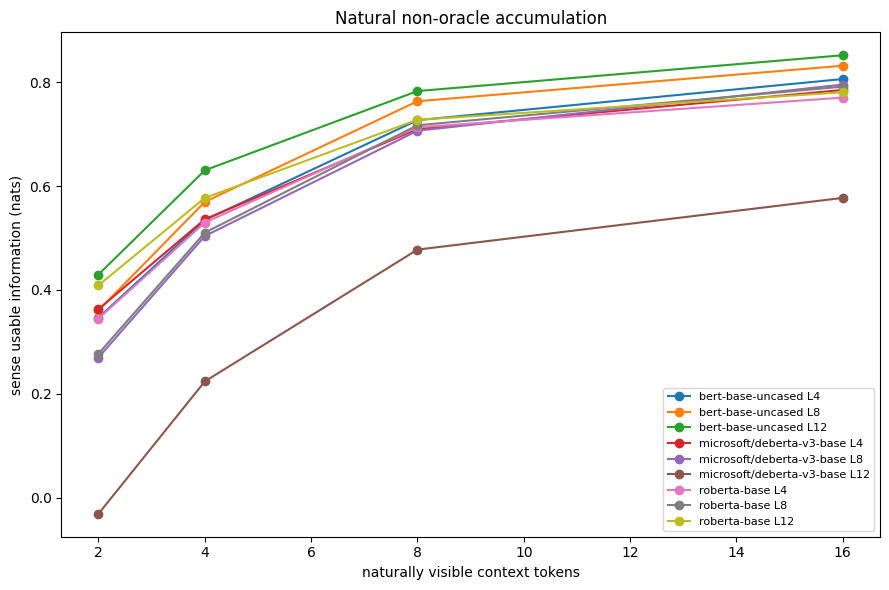

In [25]:
# Natural usable-information trajectory.
g = (
    natural_probe
    .groupby(["model", "layer", "visible_m"])
    ["usable_info_nats"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 6))

for (model, layer), gm in g.groupby(
    ["model", "layer"]
):
    gm = gm.sort_values("visible_m")
    plt.plot(
        gm["visible_m"],
        gm["usable_info_nats"],
        marker="o",
        label=f"{model} L{layer}",
    )

plt.xlabel("naturally visible context tokens")
plt.ylabel("sense usable information (nats)")
plt.title("Natural non-oracle accumulation")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(
    PLOT_DIR / "01_natural_sense_information.png",
    bbox_inches="tight",
)
plt.show()

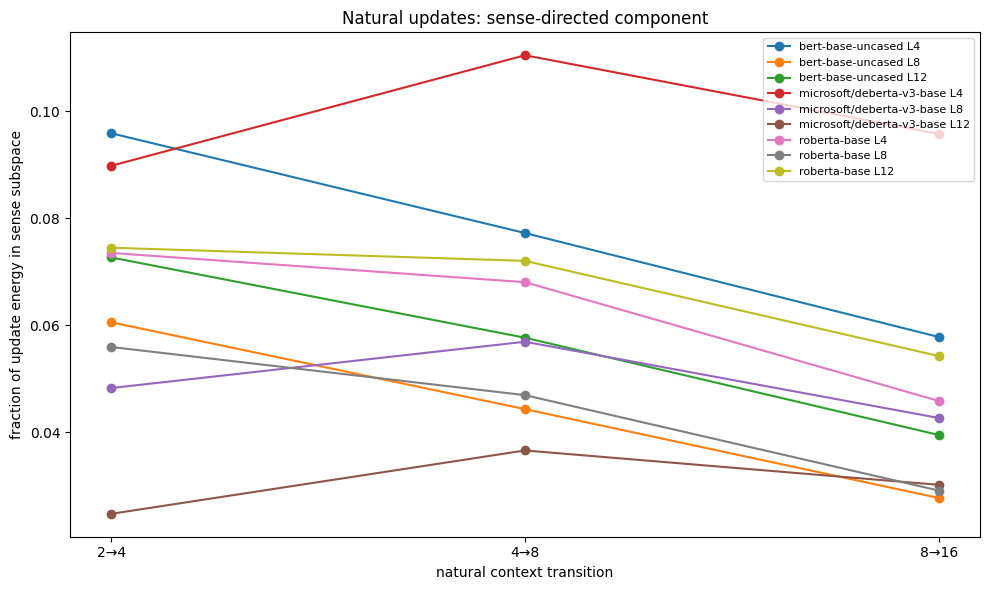

In [26]:
# Natural update sense-energy fraction.
g = (
    natural_updates
    .groupby([
        "model",
        "layer",
        "prev_m",
        "visible_m",
    ])
    ["mean_sense_energy_fraction"]
    .mean()
    .reset_index()
)

g["transition"] = (
    g["prev_m"].astype(str)
    + "→"
    + g["visible_m"].astype(str)
)

plt.figure(figsize=(10, 6))

for (model, layer), gm in g.groupby(
    ["model", "layer"]
):
    plt.plot(
        gm["transition"],
        gm["mean_sense_energy_fraction"],
        marker="o",
        label=f"{model} L{layer}",
    )

plt.xlabel("natural context transition")
plt.ylabel("fraction of update energy in sense subspace")
plt.title("Natural updates: sense-directed component")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(
    PLOT_DIR / "02_natural_update_sense_energy.png",
    bbox_inches="tight",
)
plt.show()

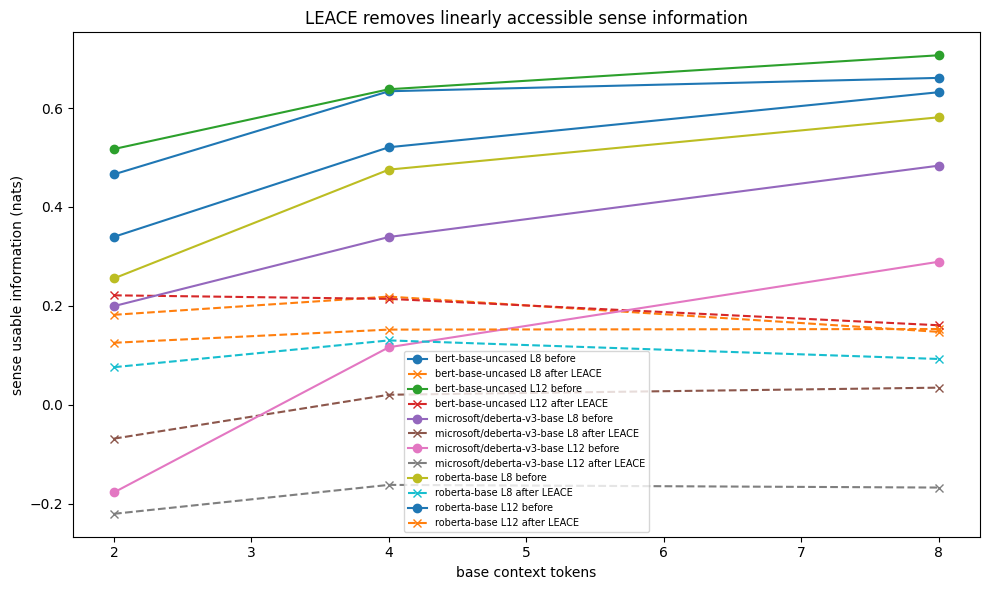

In [27]:
# LEACE: sense usable information before / after.
g = (
    leace_results
    .groupby(["model", "layer", "base_m"])[[
        "sense_usable_before",
        "sense_usable_after",
    ]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

for (model, layer), gm in g.groupby(
    ["model", "layer"]
):
    gm = gm.sort_values("base_m")
    plt.plot(
        gm["base_m"],
        gm["sense_usable_before"],
        marker="o",
        label=f"{model} L{layer} before",
    )
    plt.plot(
        gm["base_m"],
        gm["sense_usable_after"],
        marker="x",
        linestyle="--",
        label=f"{model} L{layer} after LEACE",
    )

plt.xlabel("base context tokens")
plt.ylabel("sense usable information (nats)")
plt.title("LEACE removes linearly accessible sense information")
plt.legend(fontsize=7)
plt.tight_layout()
plt.savefig(
    PLOT_DIR / "03_leace_sense_erasure.png",
    bbox_inches="tight",
)
plt.show()

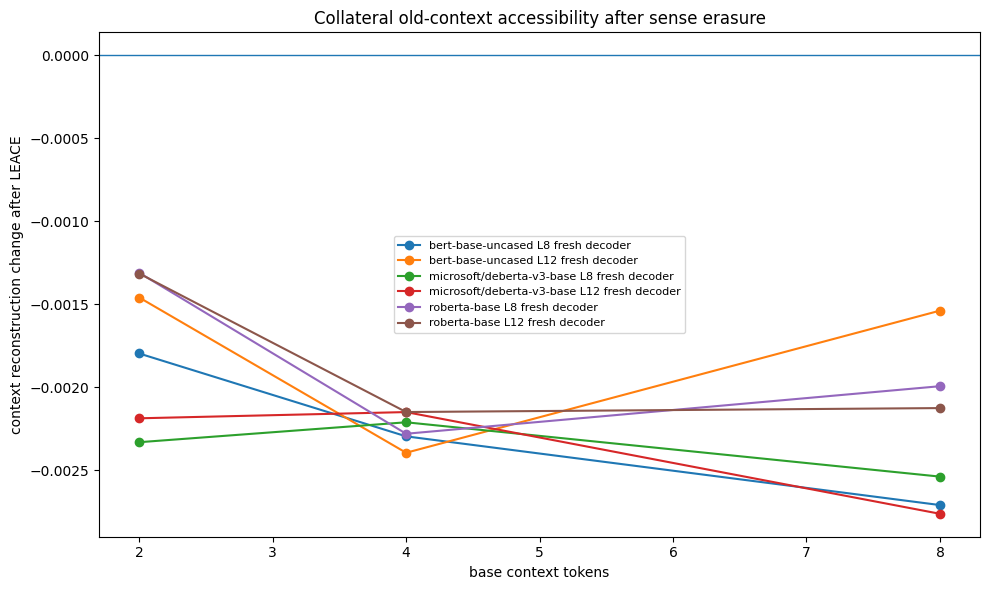

In [28]:
# LEACE collateral context loss.
g = (
    leace_results
    .groupby(["model", "layer", "base_m"])[[
        "delta_context_fresh",
        "delta_context_frozen",
    ]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

for (model, layer), gm in g.groupby(
    ["model", "layer"]
):
    gm = gm.sort_values("base_m")
    plt.plot(
        gm["base_m"],
        gm["delta_context_fresh"],
        marker="o",
        label=f"{model} L{layer} fresh decoder",
    )

plt.axhline(0, linewidth=1)
plt.xlabel("base context tokens")
plt.ylabel("context reconstruction change after LEACE")
plt.title("Collateral old-context accessibility after sense erasure")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(
    PLOT_DIR / "04_leace_context_collateral.png",
    bbox_inches="tight",
)
plt.show()

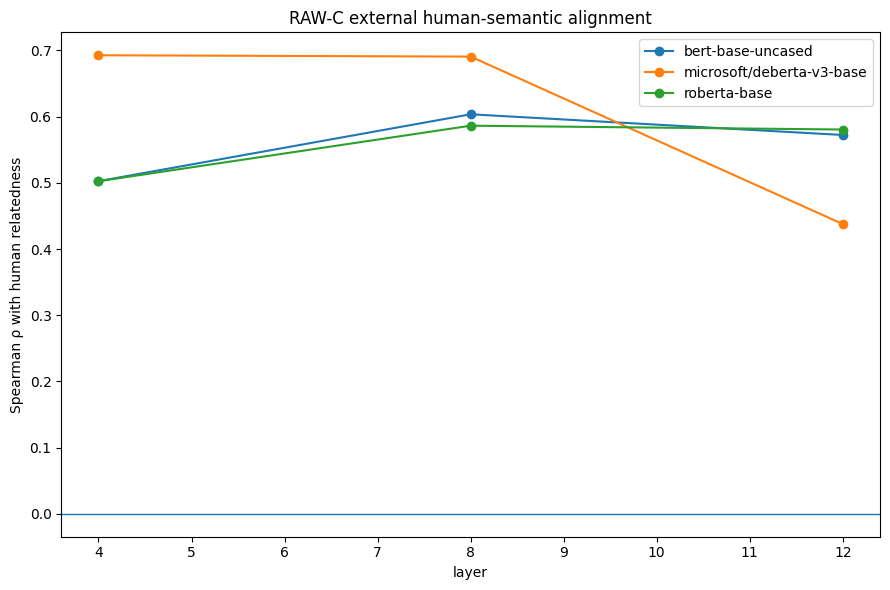

In [29]:
# RAW-C human-relatedness alignment.
plt.figure(figsize=(9, 6))

for model, gm in rawc_summary.groupby("model"):
    gm = gm.sort_values("layer")
    plt.plot(
        gm["layer"],
        gm["spearman_human_relatedness"],
        marker="o",
        label=model,
    )

plt.axhline(0, linewidth=1)
plt.xlabel("layer")
plt.ylabel("Spearman ρ with human relatedness")
plt.title("RAW-C external human-semantic alignment")
plt.legend()
plt.tight_layout()
plt.savefig(
    PLOT_DIR / "05_rawc_human_alignment.png",
    bbox_inches="tight",
)
plt.show()

# 18. Final decision table

This notebook is designed to end the project rather than create V6.

### Natural validation passes if

- usable sense information generally rises with natural context;
- transitions with more diagnostic natural evidence show larger sense-information gain and/or more sense-directed updates;
- normalized sense geometry strengthens with natural context.

### LEACE validation passes if

- sense usable information collapses after erasure;
- old-context accessibility is not destroyed to the same degree;
- any loss is reported honestly as evidence of sense/context entanglement.

### RAW-C validation passes if

- contextual geometry has positive, non-trivial correlation with graded human relatedness;
- same-sense pairs are more separable from different-sense pairs than chance.

No single failed condition kills the paper. What matters is whether the **central V4 mechanism is robust to non-oracle context and whether its semantic geometry has external validity**.

In [30]:
final_decision_rows = []

# Natural average direction.
for (model, layer), g in natural_joint.groupby(
    ["model", "layer"]
):
    final_decision_rows.append({
        "validation": "natural",
        "model": model,
        "layer": int(layer),
        "sense_gain_mean": float(
            g["delta_usable_info"].mean()
        ),
        "sense_gain_positive_fraction": float(
            (g["delta_usable_info"] > 0).mean()
        ),
        "sense_energy_mean": float(
            g["mean_sense_energy_fraction"].mean()
        ),
        "extra_1": float(
            spearmanr(
                g["mean_new_token_gold_pmi"],
                g["delta_usable_info"],
            )[0]
        ),
        "extra_2": np.nan,
    })

# LEACE.
for (model, layer), g in leace_results.groupby(
    ["model", "layer"]
):
    final_decision_rows.append({
        "validation": "leace",
        "model": model,
        "layer": int(layer),
        "sense_gain_mean": float(
            (
                g["sense_usable_before"]
                - g["sense_usable_after"]
            ).mean()
        ),
        "sense_gain_positive_fraction": float(
            (
                g["sense_usable_before"]
                > g["sense_usable_after"]
            ).mean()
        ),
        "sense_energy_mean": np.nan,
        "extra_1": float(
            g["delta_context_fresh"].mean()
        ),
        "extra_2": float(
            g["delta_context_frozen"].mean()
        ),
    })

# RAW-C.
for _, r in rawc_summary.iterrows():
    final_decision_rows.append({
        "validation": "rawc",
        "model": r["model"],
        "layer": int(r["layer"]),
        "sense_gain_mean": np.nan,
        "sense_gain_positive_fraction": np.nan,
        "sense_energy_mean": np.nan,
        "extra_1": float(
            r["spearman_human_relatedness"]
        ),
        "extra_2": float(
            r["same_vs_diff_auc"]
        ),
    })

final_decision = pd.DataFrame(
    final_decision_rows
)

final_decision.to_csv(
    RESULT_DIR / "FINAL_DECISION_TABLE.csv",
    index=False,
)

display(final_decision)

,validation,model,layer,sense_gain_mean,sense_gain_positive_fraction,sense_energy_mean,extra_1,extra_2
0,natural,bert-base-uncased,4,0.153175,0.929825,0.077000,0.075188,NaN
1,natural,bert-base-uncased,8,0.157047,0.894737,0.044203,0.044983,NaN
2,natural,bert-base-uncased,12,0.140746,0.912281,0.056627,0.069095,NaN
3,natural,microsoft/deberta-v3-base,4,0.140692,0.894737,0.098712,0.119717,NaN
4,natural,microsoft/deberta-v3-base,8,0.175213,0.877193,0.049300,0.093726,NaN
5,natural,microsoft/deberta-v3-base,12,0.202803,0.859649,0.030515,-0.045955,NaN
6,natural,roberta-base,4,0.141844,0.912281,0.062492,0.075836,NaN
7,natural,roberta-base,8,0.171453,0.877193,0.044002,0.037464,NaN
8,natural,roberta-base,12,0.123910,0.947368,0.066945,0.181877,NaN
9,leace,bert-base-uncased,8,0.404319,0.912281,NaN,-0.002266,-0.002242


# 19. Save metadata and package results

The ZIP excludes large embedding caches.

After execution, upload:

1. `semantic_disambiguation_geometry_v5_final_results.zip`
2. the executed notebook

Then stop experimenting unless V5 exposes a genuine methodological failure.

In [31]:
train_sampling.to_csv(
    RESULT_DIR / "train_sampling.csv",
    index=False,
)

test_sampling.to_csv(
    RESULT_DIR / "test_sampling.csv",
    index=False,
)

config = {
    "profile": PROFILE,
    "dataset": DATASET_ID,
    "eligible_words": VALID_WORDS,
    "models": MODELS,
    "layers": LAYERS,
    "leace_layers": LEACE_LAYERS,
    "natural_visible_counts": NATURAL_VISIBLE_COUNTS,
    "leace_base_sizes": LEACE_BASE_SIZES,
    "raw_c_url": RAW_C_URL,
    "seed": SEED,
    "bootstrap_iters": BOOTSTRAP_ITERS,
}

with open(
    RESULT_DIR / "config.json",
    "w",
) as f:
    json.dump(
        config,
        f,
        indent=2,
    )

print("RESULT FILES")
for p in sorted(RESULT_DIR.iterdir()):
    print(" ", p.name)

print("\nPLOTS")
for p in sorted(PLOT_DIR.iterdir()):
    print(" ", p.name)

RESULT FILES
  FINAL_DECISION_TABLE.csv
  config.json
  leace_causal_erasure_per_word.csv
  leace_causal_erasure_summary.csv
  leace_headline_bootstrap.csv
  natural_covariance_geometry_per_word.csv
  natural_headline_bootstrap.csv
  natural_information_geometry_joint.csv
  natural_sense_accessibility_per_word.csv
  natural_transition_correlations.csv
  natural_update_trajectory_per_word.csv
  rawc_external_replication.csv
  test_sampling.csv
  train_sampling.csv

PLOTS
  01_natural_sense_information.png
  02_natural_update_sense_energy.png
  03_leace_sense_erasure.png
  04_leace_context_collateral.png
  05_rawc_human_alignment.png


In [32]:
export_dir = ROOT / "resource_export"
export_dir.mkdir(exist_ok=True)

for src_dir in [RESULT_DIR, PLOT_DIR]:
    dst = export_dir / src_dir.name

    if dst.exists():
        shutil.rmtree(dst)

    shutil.copytree(
        src_dir,
        dst,
    )

archive = shutil.make_archive(
    "semantic_disambiguation_geometry_v5_final_results",
    "zip",
    root_dir=export_dir,
)

print("RESULT ARCHIVE:", archive)
print("Embedding caches remain under:", CACHE_DIR)

RESULT ARCHIVE: /kaggle/working/semantic_disambiguation_geometry_v5_final_results.zip
Embedding caches remain under: semantic_disambiguation_geometry_v5_final/cache


# STOP RULE

If the full resource run finishes without a design failure, **V5 is the final experimental version**.

Possible conclusions after V5:

### Outcome A — strongest

Natural accumulation, LEACE, and RAW-C all broadly align.

Then write the paper around:

\[
\boxed{
\textbf{sense-directed contextual reorganization}
}
\]

with causal-linear and external-semantic validation.

### Outcome B — natural succeeds, LEACE shows collateral context loss

This is still interesting:

> sense and pre-existing contextual information are partially entangled; disambiguation reorganizes rather than cleanly appends a sense-only subspace.

### Outcome C — oracle V4 does not survive natural context

Then the gold-PMI intervention was creating a special regime.

The paper narrows to:

> controlled diagnostic evidence induces structured geometry, but natural evidence accumulation is weaker / more heterogeneous.

### Outcome D — RAW-C alignment weak

Do not claim human-like semantic geometry. Keep the paper about model-internal lexical disambiguation.

There is no planned V6.